## 03 Dynamic Model: Differential Equations

Solves the differential equation of the customer system and fit the damping coefficient γ from the real data.

-> Main Equation: $$\frac{dE}{dt} = -\gamma \cdot E + F(t)$$

-> Analytical solution (no perturbations): $E(t) = E_0 \cdot e^{-\gamma t}$

### Setup

In [1]:
import os
import sqlite3
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
sys.path.insert(0, ROOT)
os.chdir(os.path.join(ROOT, 'notebooks'))

sys.path.insert(0, os.path.abspath('..'))
os.makedirs('../figures', exist_ok=True)

from src.physics import (  # noqa: E402
    E_CRITICAL,
    E_EQ_BASE,
    no_perturbation,
    periodic_perturbation,
    solve_trajectory,
    step_perturbation,
)
from src.visualization import PALETTE, set_style  # noqa: E402

set_style()

try:
    LIFELINES_OK = True
except Exception:
    LIFELINES_OK = False

DATA_DIR = os.path.join(ROOT, 'data')
df_clean = pd.read_csv(os.path.join(DATA_DIR, 'telco_clean.csv'))
df_features = pd.read_csv(os.path.join(DATA_DIR, 'telco_features.csv'))
df_final = pd.read_csv(os.path.join(DATA_DIR, 'telco_final.csv'))
df = df_features.copy()
df_model = pd.get_dummies(df, columns=['Contract','PaymentMethod','InternetService'], drop_first=True)

conn = sqlite3.connect(':memory:')
df.to_sql('telco', conn, if_exists='replace', index=False)
df_clean.to_sql('telco_clean', conn, if_exists='replace', index=False)

print(f'Ready: {len(df):,} customers | churn rate {df.Churn_bin.mean():.1%}')


Ready: 7,043 customers | churn rate 26.5%


In [2]:
# Load real dataset
df_clean = pd.read_csv(os.path.join(DATA_DIR, 'telco_clean.csv'))
df_features = pd.read_csv(os.path.join(DATA_DIR, 'telco_features.csv'))
df_final = pd.read_csv(os.path.join(DATA_DIR, 'telco_final.csv'))
df = df_features.copy()   

print(f'Dataset: {len(df):,} customers | Churn rate: {df["Churn_bin"].mean():.1%}')
print('Physical columns:', [c for c in df.columns if c in ['E0','E_eq','gamma','tau','resilience','physical_state','intrinsic_risk']])

Dataset: 7,043 customers | Churn rate: 26.5%
Physical columns: ['E_eq', 'gamma', 'tau', 'resilience', 'E0', 'physical_state', 'intrinsic_risk']


### Simulated trajectories: representative customers


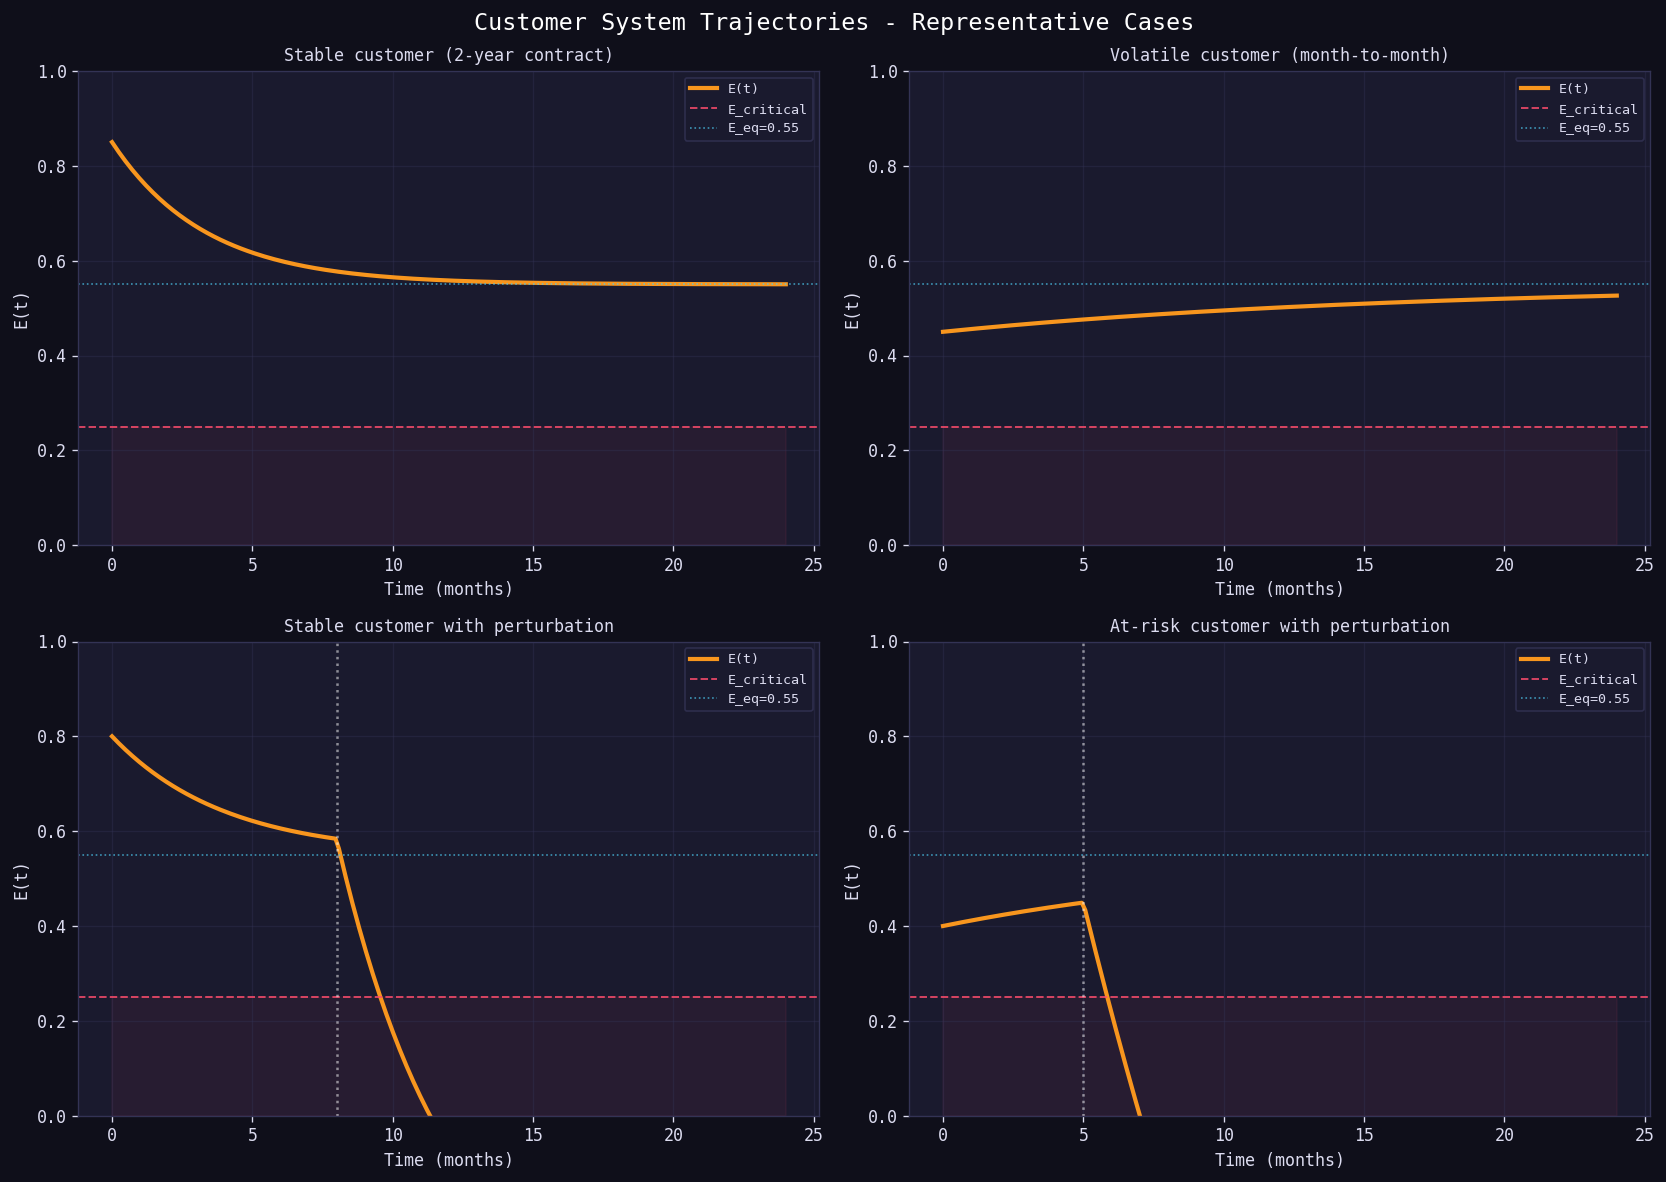

Figure saved


In [3]:
fig, axes = plt.subplots(2,2, figsize=(14,10))
fig.suptitle('Customer System Trajectories - Representative Cases', fontsize=14, color='white')


cases = [
    {'title': 'Stable customer (2-year contract)', 'E0': 0.85, 'gamma': 0.30, 'event_t': None},
    {'title': 'Volatile customer (month-to-month)', 'E0': 0.45, 'gamma': 0.06, 'event_t': None},
    {'title': 'Stable customer with perturbation', 'E0': 0.80, 'gamma': 0.25, 'event_t': 8},
    {'title': 'At-risk customer with perturbation', 'E0': 0.40, 'gamma': 0.08, 'event_t': 5},]

for ax, case in zip(axes.flatten(), cases):
    F = (lambda t: step_perturbation(t, case['event_t'], 0.25)) if case['event_t'] else no_perturbation
    sol = solve_trajectory(case['E0'], case['gamma'], F, (0, 24), E_eq=E_EQ_BASE)
    t, E = sol.t, sol.y[0]
    ax.plot(t, E, color=PALETTE['accent'], linewidth=2.5, label='E(t)')
    ax.axhline(E_CRITICAL, color=PALETTE['churn'], linestyle='--', linewidth=1.2, alpha=0.8, label='E_critical')
    ax.axhline(E_EQ_BASE, color=PALETTE['no_churn'], linestyle=':', linewidth=1, alpha=0.7, label=f'E_eq={E_EQ_BASE}')
    ax.fill_between(t, 0, E_CRITICAL, alpha=0.06, color=PALETTE['churn'])
    if case['event_t']:
        ax.axvline(case['event_t'], color='white', linestyle=':', alpha=0.5)
    ax.set_title(case['title'], fontsize=10)
    ax.set_xlabel('Time (months)')
    ax.set_ylabel('E(t)')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
os.makedirs('../plots', exist_ok=True)
plt.savefig(os.path.join(ROOT, 'plots', '03_trajectories.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Figure saved")

### Fitting γ from real data by contract segment

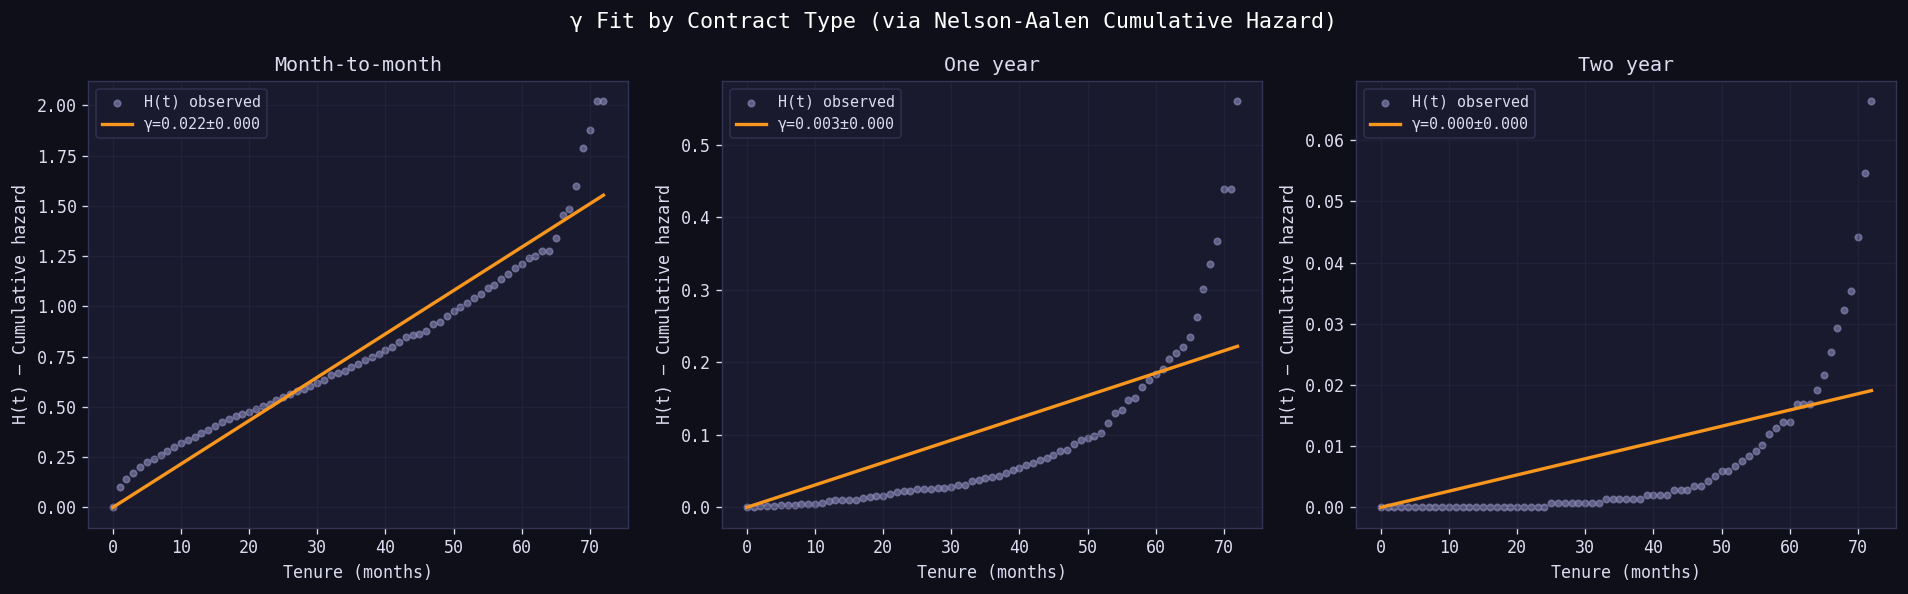

Fitted parameters (Nelson-Aalen method)
Month-to-month: γ = 0.0216 ± 0.0004 | τ = 46.3 months
One year: γ = 0.0031 ± 0.0002 | τ = 324.0 months
Two year: γ = 0.0003 ± 0.0000 | τ = ∞ (fit did not converge) months


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('γ Fit by Contract Type (via Nelson-Aalen Cumulative Hazard)', fontsize=13, color='white')

# Method: Nelson-Aalen cumulative hazard H(t) = γ·t for exponential distribution.
# Fitting a line through H(t) gives γ directly -> avoids survival bias of the cumulative churn proxy used in v1.
try:
    from lifelines import NelsonAalenFitter
    LIFELINES_OK = True
except ImportError:
    LIFELINES_OK = False

contracts = ['Month-to-month', 'One year', 'Two year']
fit_results = {}

for ax, contract in zip(axes, contracts):
    subset = df[df['Contract'] == contract].copy()

    if LIFELINES_OK:
        naf = NelsonAalenFitter()
        naf.fit(durations=subset['tenure'], event_observed=subset['Churn_bin'], label=contract)

        # H(t) = gamma * t => gamma = slope via linear regression through origin
        t_obs = naf.cumulative_hazard_.index.values
        H_obs = naf.cumulative_hazard_[contract].values

        # Linear fit: H = gamma * t (through origin)
        mask = t_obs > 0
        gamma_est = np.dot(t_obs[mask], H_obs[mask]) / np.dot(t_obs[mask], t_obs[mask])
        residuals = H_obs[mask] - gamma_est * t_obs[mask]
        sigma_gamma = np.std(residuals) / np.sqrt(np.sum(t_obs[mask]**2))

        fit_results[contract] = {'gamma': gamma_est, 'sigma_gamma': sigma_gamma}

        t_fit = np.linspace(0, t_obs.max(), 200)
        H_fit = gamma_est * t_fit

        ax.scatter(t_obs, H_obs, color=PALETTE['neutral'], s=15, alpha=0.6, label='H(t) observed')
        ax.plot(t_fit, H_fit, color=PALETTE['accent'], linewidth=2, label=f'γ={gamma_est:.3f}±{sigma_gamma:.3f}')
        ax.set_ylabel('H(t) - Cumulative hazard')
    else:
        ax.text(0.5, 0.5, 'lifelines not installed', transform=ax.transAxes, ha='center')

    ax.set_title(contract)
    ax.set_xlabel('Tenure (months)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '03_gamma_fit.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print('Fitted parameters (Nelson-Aalen method)')
for contract, res in fit_results.items():
    tau = 1 / res['gamma'] if res['gamma'] > 0.001 else float('inf')
    tau_str = f"{tau:.1f}" if tau < 10000 else "∞ (fit did not converge)"
    print(f'{contract}: γ = {res["gamma"]:.4f} ± {res["sigma_gamma"]:.4f} | τ = {tau_str} months')

# Note: gamma values from Nelson-Aalen (0.002-0.02) are in hazard rate scale (probability of churn per month)
# These differ from the physics model's gamma (0.08-0.30), which represents loyalty friction calibrated per contract type. 
# Both capture the same hierarchy (month-to-month > one year > two year) but at different scales. 
# The Nelson-Aalen gamma is empirical; the model's gamma is a design choice encoding contractual friction.


### Effect of different perturbation types

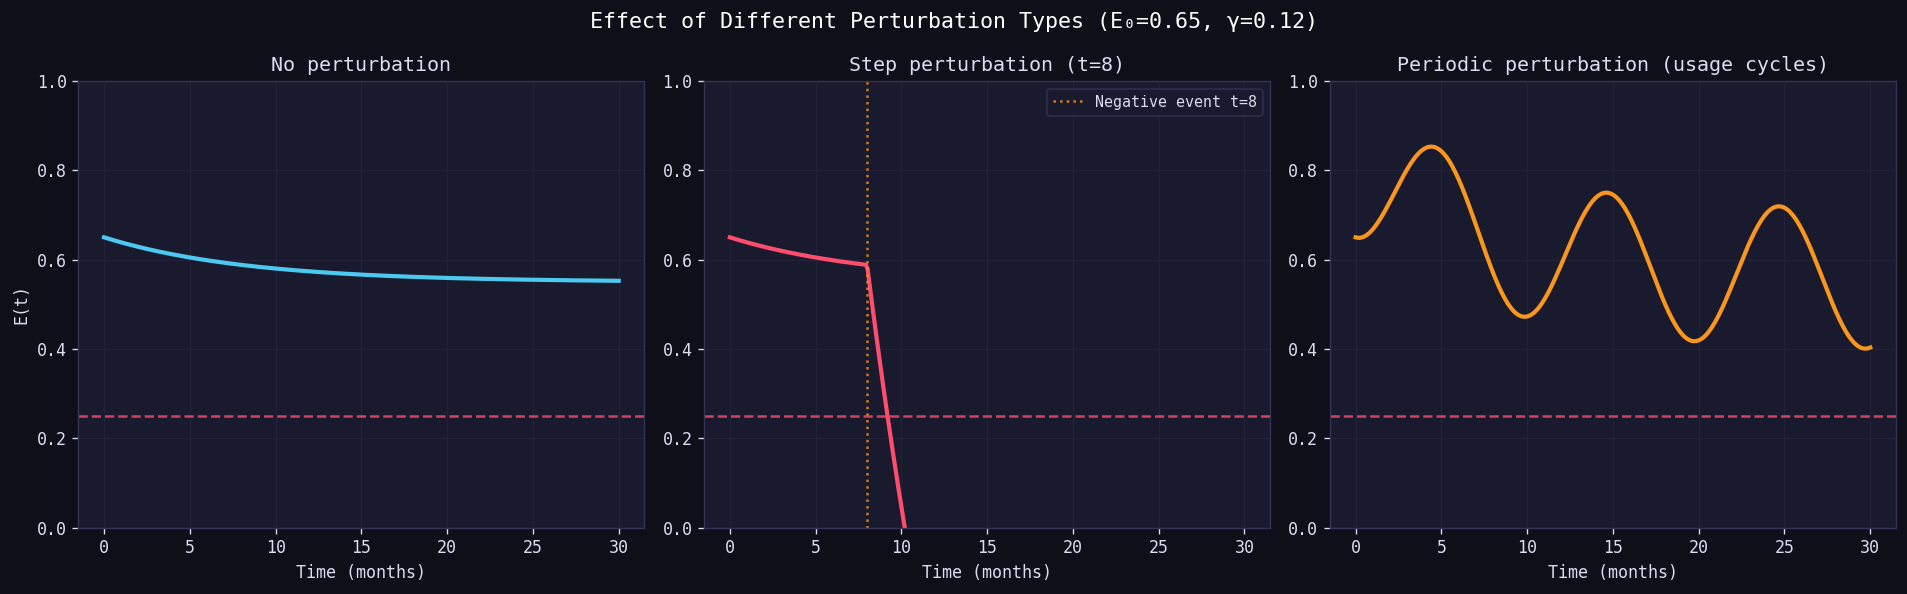

In [5]:
fig, axes = plt.subplots(1,3, figsize=(16,5))
fig.suptitle('Effect of Different Perturbation Types (E₀=0.65, γ=0.12)', fontsize=13, color='white')

E0, gamma, t_fin = 0.65, 0.12, 30
t_eval = np.linspace(0, t_fin, 300)

# No perturbation
sol0 = solve_trajectory(E0, gamma, lambda t: 0, (0, t_fin), t_eval)
axes[0].plot(sol0.t, sol0.y[0], color=PALETTE['no_churn'], linewidth=2.5)
axes[0].axhline(E_CRITICAL, color=PALETTE['churn'], linestyle='--', alpha=0.8)
axes[0].set_title('No perturbation')
axes[0].set_xlabel('Time (months)')
axes[0].set_ylabel('E(t)')
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1)

# Step perturbation
sol1 = solve_trajectory(E0, gamma, lambda t: step_perturbation(t, 8, 0.3), (0, t_fin), t_eval)
axes[1].plot(sol1.t, sol1.y[0], color=PALETTE['churn'], linewidth=2.5)
axes[1].axvline(8, color=PALETTE['accent'], linestyle=':', alpha=0.8, label='Negative event t=8')
axes[1].axhline(E_CRITICAL, color=PALETTE['churn'], linestyle='--', alpha=0.8)
axes[1].set_title('Step perturbation (t=8)')
axes[1].set_xlabel('Time (months)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)

# Periodic
sol2 = solve_trajectory(E0, gamma, lambda t: periodic_perturbation(t, 0.1, 0.1), (0, t_fin), t_eval)
axes[2].plot(sol2.t, sol2.y[0], color=PALETTE['accent'], linewidth=2.5)
axes[2].axhline(E_CRITICAL, color=PALETTE['churn'], linestyle='--', alpha=0.8)
axes[2].set_title('Periodic perturbation (usage cycles)')
axes[2].set_xlabel('Time (months)')
axes[2].grid(alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '03_perturbations.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()